In [1]:
import requests
from bs4 import BeautifulSoup

import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt

## First request

In [2]:
url = "http://books.toscrape.com/"
response = requests.get(url)
soup = BeautifulSoup(response.content, "html.parser")
type(soup)

bs4.BeautifulSoup

In [3]:
books_html = soup.find_all("article", class_="product_pod")
len(books_html)

20

## Parsing _one_ book

In [4]:
book_title = books_html[0].find("h3").find("a").attrs["title"]
book_title

'A Light in the Attic'

In [5]:
book_price = float(books_html[0].find("p", class_="price_color").text[1:])
book_price

51.77

In [6]:
price_text = books_html[0].find("p", class_="price_color").text
book_price = float(price_text.replace("Â", "").replace("£", "").strip())

In [7]:
def parse_rating(rating_classes):
    ratings = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}
    for rating in ratings:
        if rating in rating_classes:
            return ratings[rating]

In [8]:
book_rating = parse_rating(books_html[0].find("p", class_="star-rating").attrs["class"])
book_rating

3

## Parsing _all_ books (first page)

In [9]:
books_dict = {"Title": [], "Price": [], "Rating": []}

for book in books_html:
    title = book.find("h3").find("a").attrs["title"]
    price = float(book.find("p", class_="price_color").text[1:])
    rating = parse_rating(book.find("p", class_="star-rating").attrs["class"])
    books_dict["Title"].append(title)
    books_dict["Price"].append(price)
    books_dict["Rating"].append(rating)

len(books_dict["Title"])   # expect 20

20

## Load into Pandas

In [10]:
books_df = pd.DataFrame(books_dict)
books_df.head()

,Title,Price,Rating
0,A Light in the Attic,51.77,3
1,Tipping the Velvet,53.74,1
2,Soumission,50.10,1
3,Sharp Objects,47.82,4
4,Sapiens: A Brief History of Humankind,54.23,5


<Axes: xlabel='Rating'>

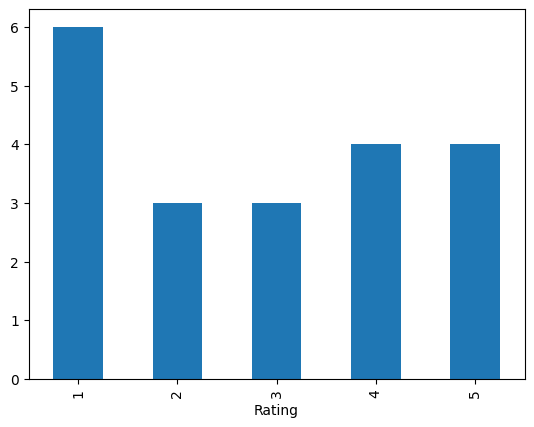

In [11]:
books_df.groupby("Rating").count()["Title"].plot(kind="bar")

In [12]:
from nbresult import ChallengeResult

result = ChallengeResult('books',
    columns=books_df.columns,
    title=str(books_df.loc[0, 'Title']),
    price=books_df.loc[0, 'Price'],
    rating=books_df.loc[0, 'Rating'])
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/lemfi/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/lemfi/code/workintechpoyrazaka-sketch/data-book-scraping/tests
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 5 items

test_books.py::TestBooks::test_books_df_columns_name PASSED              [ 20%]
test_books.py::TestBooks::test_books_df_columns_size PASSED              [ 40%]
test_books.py::TestBooks::test_first_book_price PASSED                   [ 60%]
test_books.py::TestBooks::test_first_book_rating PASSED                  [ 80%]
test_books.py::TestBooks::test_first_book_title PASSED                   [100%]

============================== 5 passed in 0.45s ===============================


💯 You can commit your code:

git add tests/books.pickle

git commit -m 'Completed books step'

git push origin master

